# Basic Maps

Author : Henry Nachman

Date : 10 September 2026

---

This notebook will step through how to create a 'simulated' basic CMB maps with a single point source in Healpy.

In [70]:
import healpy as hp
import os
import numpy as np
from astropy import units as u
import matplotlib.pyplot as plt
import matplotlib

# Define the output directory for the maps
out_dir = "/shared_home/henachman/SO_PointingReqs/sim_sky_maps/maps/"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

# Matplotlib settings
matplotlib.style.use('/shared_home/henachman/.matplotlib/stylelib/HNCustomMono.mplstyle')

lat_fwhm = 200*u.arcsec
# Define the coordinates of the point source in sky coordinates
lon = 290.0 * u.deg
lat = -60.0 * u.deg
source_size = (1*lat_fwhm).to(u.rad)

## High Resolution Small Map

201326592
[ 0.17101007 -0.46984631 -0.8660254 ]
[0. 0. 0. ... 0. 0. 0.]
201326592


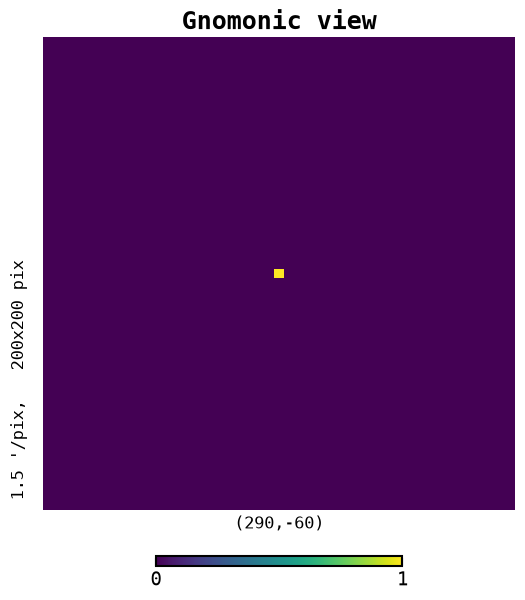

In [71]:
nside = 2**12
npix = hp.nside2npix(nside)
print(npix)
empty_map = np.zeros(npix)

vec = hp.ang2vec(lon.value, lat.value, lonlat=True)
print(vec)
# Convert the sky coordinates to pixel indices in the HEALPix map
# Find the indices of all the pixels within x degrees of that point

pixel_inds = hp.query_disc(nside, vec=vec, radius=source_size.value, nest=True)

# Add a point source
empty_map[pixel_inds] += 1  # Add a point source with an amplitude of 1 microK

print(empty_map)
print(hp.pixelfunc.get_map_size(empty_map))
hp.gnomview(empty_map, rot=[lon.value, lat.value], xsize=200, nest=True)

## With Cls

824.5167388361774 arcsec


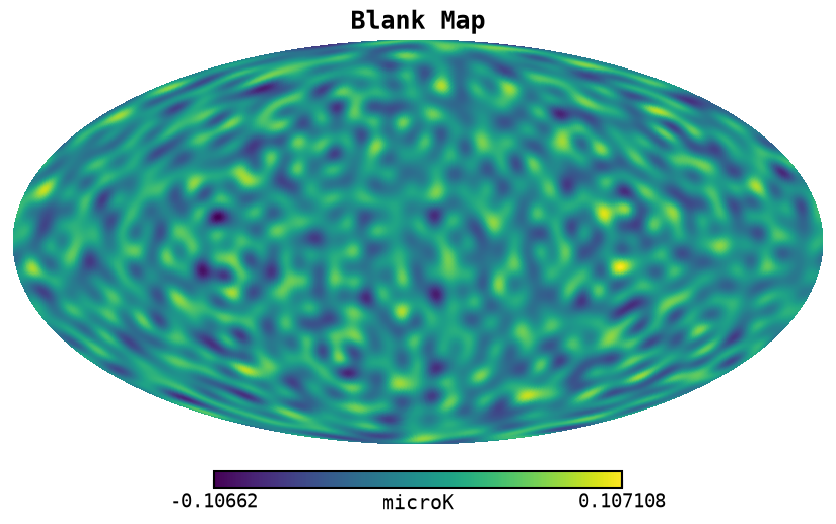

In [72]:
nside = 2**8

output_file = os.path.join(out_dir, "blank_map.fits")

# We will create a blank map
print((hp.pixelfunc.nside2resol(nside, arcmin=True)*u.arcmin).to(u.arcsec))
# create a Cl array with zeros
cl = np.zeros((4, hp.sphtfunc.Alm.getsize(nside)))


# The current Cls are 0 - but you can adjust
cl[:, 15] = 10
cl[:, 25] = 5
cl[:, 35] = 5

# Create a blank map using the Cl array
map_ring = hp.synfast(cl, nside=nside, fwhm=lat_fwhm.to_value(u.radian))
output_map = 3e-3 * hp.reorder(map_ring, inp='RING', out='NEST')  # Convert to NESTED ordering and scale to microK  
# Save the blank map to a FITS file
# hp.write_map(output_file, output_map, nest=True, overwrite=True)

hp.mollview(output_map[0], title="Blank Map", unit="microK", nest=True)

### Point Source

Now we want to add a point source right in the middle of our map

setting the output map dtype to [dtype('float64'), dtype('float64'), dtype('float64')]


[732845 732850 732856] 1


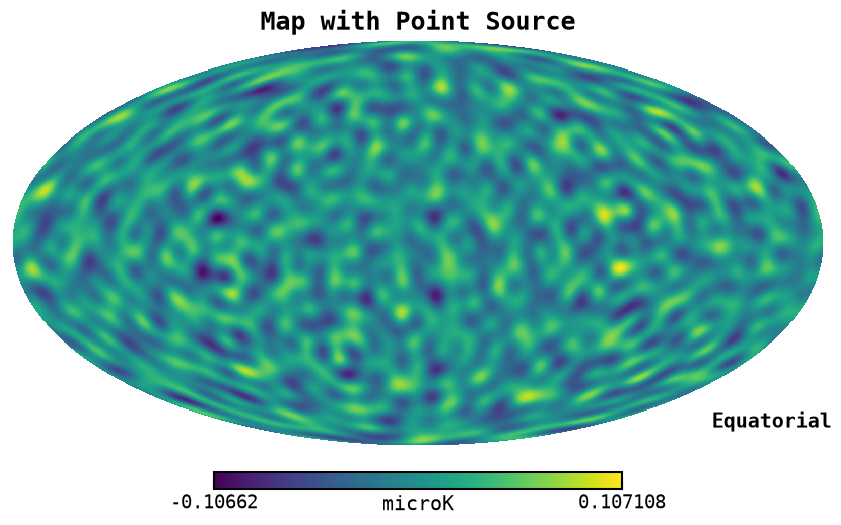

In [77]:

# Find the vector that points to that point
vec = hp.ang2vec(lon.value, lat.value, lonlat=True)

# Convert the sky coordinates to pixel indices in the HEALPix map
# Find the indices of all the pixels within x degrees of that point
source_size = (3*lat_fwhm).to(u.rad)
pixel_inds = hp.query_disc(nside, vec=vec, radius=source_size.value, nest=True)
# Add a point source to the map at the specified pixel index
print(pixel_inds, int(len(pixel_inds)/2))
output_map[0, pixel_inds[1]] += 6e-2  # Add a point source with an amplitude of 1 microK
# Save the updated map with the point source to a new FITS file
output_file_with_source = os.path.join(out_dir, "map_with_1PIX_source.fits")
hp.write_map(output_file_with_source, output_map, nest=True, overwrite=True)
hp.mollview(output_map[0], title="Map with Point Source", unit="microK", nest=True, coord=["C"])

Use Gnomview to zoom in on that spot

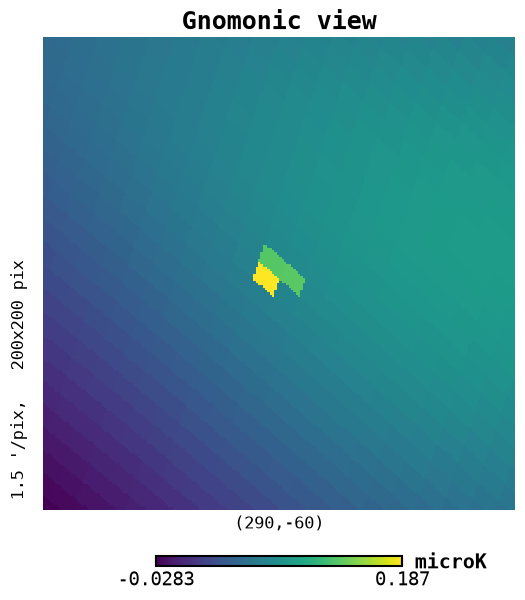

In [78]:
# Convert the vector in theta phi to lon lat
hp.gnomview(output_map[0], rot=[lon.value, lat.value], unit="microK", xsize=200, nest=True)

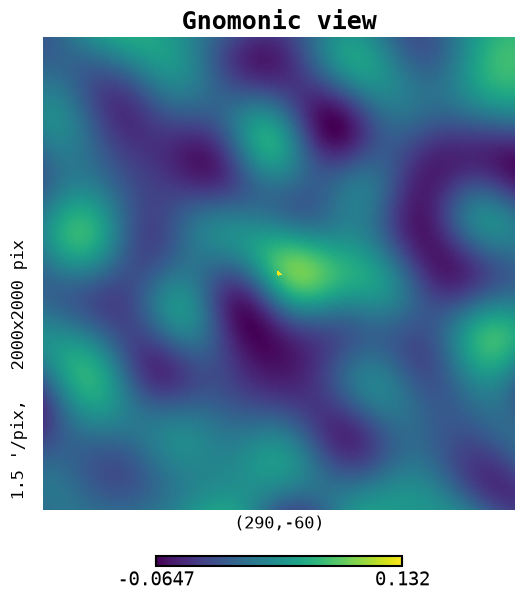

In [75]:
loaded_map = hp.read_map(output_file_with_source, nest=True)
hp.gnomview(loaded_map, rot=[lon.value, lat.value], xsize=2000, nest=True)

In [76]:
import numpy as np
import astropy.units as u
from pixell import enmap

# --- pulled straight from blank_map.ipynb ---
center_ra_deg = lon.to_value(u.deg)     # 290.0
center_dec_deg = lat.to_value(u.deg)    # -60.0

patch_width_deg = 10.0   # scheduled patch width
fov_deg = 9.9            # focal-plane FOV
padding_factor = 1.2

half_extent_deg = 0.5 * (patch_width_deg + fov_deg) * padding_factor
ra_min, ra_max = center_ra_deg - half_extent_deg, center_ra_deg + half_extent_deg
dec_min, dec_max = center_dec_deg - half_extent_deg, center_dec_deg + half_extent_deg

box = np.radians([[dec_min, ra_min], [dec_max, ra_max]])
res = np.radians(2.0 / 60.0)  # 2 arcmin

shape, wcs = enmap.geometry(box, res=res, proj="car")
enmap.write_map_geometry("area.fits", shape, wcs)
print(f"shape={shape}, RA=[{ra_min:.2f},{ra_max:.2f}], Dec=[{dec_min:.2f},{dec_max:.2f}]")

shape=(np.int64(716), np.int64(716)), RA=[278.06,301.94], Dec=[-71.94,-48.06]
